In [30]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import math
import pandas as pd

# seed (for reproducibility)
random.seed(20)
np.random.seed(20)

# PROBLEM SETTINGS 
R_MIN, R_MAX = 0.1, 1.5
H_MIN, H_MAX = 0.2, 4.0

# GA SETTINGS 
POP_SIZE = 20
NGEN     = 50
CXPB     = 0.9

ETA_C    = 15.0
ETA_M    = 20.0
INDPB    = 1.0 / 2   # mutation prob per variable

In [31]:
def water_tank(ind):
    r, h = ind

    # Volume
    V = math.pi * r**2 * h

    # Cost
    C = 500*(2*math.pi*r*h) + 700*(2*math.pi*r**2)

    # Penalty
    if V < 1:
        P = 100000*(1 - V)**2
    else:
        P = 0

    F = C + P

    return (F,)

In [32]:
if not hasattr(creator, "FitnessMin"):
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

toolbox.register("attr_r", random.uniform, R_MIN, R_MAX)
toolbox.register("attr_h", random.uniform, H_MIN, H_MAX)

toolbox.register("individual",
    tools.initCycle, creator.Individual,
    (toolbox.attr_r, toolbox.attr_h), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", water_tank)

toolbox.register("select", tools.selTournament, tournsize=2)

toolbox.register("mate",
    tools.cxSimulatedBinaryBounded,
    low=[R_MIN, H_MIN], up=[R_MAX, H_MAX],
    eta=ETA_C)

toolbox.register("mutate",
    tools.mutPolynomialBounded,
    low=[R_MIN, H_MIN], up=[R_MAX, H_MAX],
    eta=ETA_M,
    indpb=INDPB)

In [33]:
# create population
pop = toolbox.population(n=POP_SIZE)

data = []

for i, ind in enumerate(pop, start=1):
    f = toolbox.evaluate(ind)[0]
    ind.fitness.values = (f,)

    r, h = ind
    V = math.pi*r*r*h
    C = 500*(2*math.pi*r*h) + 700*(2*math.pi*r*r)
    P = 0 if V>=1 else 100000*(1-V)**2

    data.append([i, r, h, V, C, P, f])

df_initial = pd.DataFrame(
    data,
    columns=["Index","r","h","Volume","Cost","Penalty","Objective"]
)

print("\n TABLE 1: INITIAL POPULATION \n")
print(df_initial.to_string(index=False))


 TABLE 1: INITIAL POPULATION 

 Index        r        h    Volume         Cost      Penalty    Objective
     1 1.367896 2.807766 16.505042 20295.705936     0.000000 20295.705936
     2 1.173113 3.637542 15.726697 19458.770211     0.000000 19458.770211
     3 0.463758 2.615758  1.767385  4756.938601     0.000000  4756.938601
     4 1.366924 3.514095 20.627763 23308.653613     0.000000 23308.653613
     5 0.902117 0.843637  2.156905  5970.282487     0.000000  5970.282487
     6 0.676132 3.976584  5.711148 10457.463304     0.000000 10457.463304
     7 0.244547 1.412729  0.265420  1348.380812 53960.830578 55309.211390
     8 1.430055 1.907723 12.256613 17565.358877     0.000000 17565.358877
     9 0.392114 1.404235  0.678287  2406.064142 10349.922549 12755.986691
    10 1.372090 1.475161  8.724785 14639.000687     0.000000 14639.000687
    11 0.698321 2.585199  3.960531  7816.311871     0.000000  7816.311871
    12 1.227819 2.070032  9.803827 14615.254506     0.000000 14615.254506
    13

In [34]:
data_final = []

for i, ind in enumerate(pop, start=1):
    r, h = ind
    f = ind.fitness.values[0]

    V = math.pi*r*r*h
    C = 500*(2*math.pi*r*h) + 700*(2*math.pi*r*r)
    P = 0 if V>=1 else 100000*(1-V)**2

    data_final.append([i, r, h, V, C, P, f])

df_final = pd.DataFrame(
    data_final,
    columns=["Index","r","h","Volume","Cost","Penalty","Objective"]
)

print("\n================ TABLE 2: FINAL POPULATION ================\n")
print(df_final.to_string(index=False))


================ TABLE 2: FINAL POPULATION ================

 Index        r        h    Volume         Cost      Penalty    Objective
     1 1.367896 2.807766 16.505042 20295.705936     0.000000 20295.705936
     2 1.173113 3.637542 15.726697 19458.770211     0.000000 19458.770211
     3 0.463758 2.615758  1.767385  4756.938601     0.000000  4756.938601
     4 1.366924 3.514095 20.627763 23308.653613     0.000000 23308.653613
     5 0.902117 0.843637  2.156905  5970.282487     0.000000  5970.282487
     6 0.676132 3.976584  5.711148 10457.463304     0.000000 10457.463304
     7 0.244547 1.412729  0.265420  1348.380812 53960.830578 55309.211390
     8 1.430055 1.907723 12.256613 17565.358877     0.000000 17565.358877
     9 0.392114 1.404235  0.678287  2406.064142 10349.922549 12755.986691
    10 1.372090 1.475161  8.724785 14639.000687     0.000000 14639.000687
    11 0.698321 2.585199  3.960531  7816.311871     0.000000  7816.311871
    12 1.227819 2.070032  9.803827 14615.254506   

In [35]:
best_history = []

for gen in range(1, NGEN+1):

    # selection
    parents = toolbox.select(pop, POP_SIZE)

    # crossover + mutation
    offspring = algorithms.varAnd(parents, toolbox, cxpb=CXPB, mutpb=1.0)

    # evaluate offspring
    for ind in offspring:
        ind.fitness.values = toolbox.evaluate(ind)

    # elitism
    pop = tools.selBest(pop + offspring, POP_SIZE)

    # store best
    best = tools.selBest(pop, 1)[0]
    best_history.append(best.fitness.values[0])

In [36]:
df_history = pd.DataFrame({
    "Generation": list(range(1, NGEN+1)),
    "Best F": best_history
})

print("\n TABLE 3: BEST SOLUTION HISTORY \n")
print(df_history.to_string(index=False))


 TABLE 3: BEST SOLUTION HISTORY 

 Generation      Best F
          1 3652.949313
          2 3652.949313
          3 3652.949313
          4 3459.769243
          5 3415.274353
          6 3415.274353
          7 3317.782894
          8 3303.461948
          9 3303.461948
         10 3303.461948
         11 3230.989913
         12 3230.989913
         13 3230.989913
         14 3220.555594
         15 3220.555594
         16 3220.555594
         17 3220.555594
         18 3220.555594
         19 3220.555594
         20 3165.632557
         21 3165.632557
         22 3165.632557
         23 3165.632557
         24 3160.350116
         25 3160.350116
         26 3137.985639
         27 3133.474333
         28 3133.474333
         29 3130.220002
         30 3123.320794
         31 3123.320794
         32 3123.172430
         33 3123.172430
         34 3123.159672
         35 3123.159672
         36 3115.428634
         37 3114.967918
         38 3114.967918
         39 3114.967918
     

In [37]:
best = tools.selBest(pop, 1)[0]

r, h = best
V = math.pi*r*r*h
C = 500*(2*math.pi*r*h) + 700*(2*math.pi*r*r)
P = 0 if V>=1 else 100000*(1-V)**2
F = C + P

print("\n FINAL BEST SOLUTION \n")

print(f"Best radius r        : {r:.4f}")
print(f"Best height h        : {h:.4f}")
print(f"Tank volume V        : {V:.4f}")
print(f"Material cost C      : {C:.4f}")
print(f"Penalty              : {P:.4f}")
print(f"Final objective F    : {F:.4f}")

print("\nConstraint Check:")
print("V ≥ 1 m³ → SATISFIED ✅" if V >= 1 else "V < 1 m³ → NOT SATISFIED ❌")


 FINAL BEST SOLUTION 

Best radius r        : 0.4605
Best height h        : 1.4848
Tank volume V        : 0.9894
Material cost C      : 3081.1991
Penalty              : 11.2320
Final objective F    : 3092.4310

Constraint Check:
V < 1 m³ → NOT SATISFIED ❌


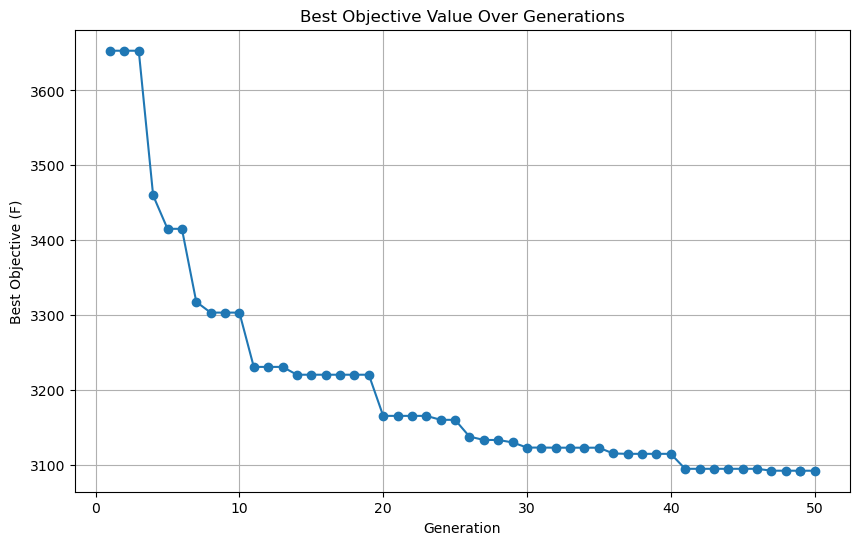

In [38]:
import matplotlib.pyplot as plt

generations = list(range(1, NGEN+1))

plt.figure(figsize=(10,6))

plt.plot(generations, best_history, marker='o')

# highlight best point
best_gen = best_history.index(min(best_history)) + 1
best_val = min(best_history)

plt.scatter(best_gen, best_val)

plt.title("Best Objective Value Over Generations")
plt.xlabel("Generation")
plt.ylabel("Best Objective (F)")

plt.grid()

plt.show()

### Bonus Task

In [39]:
print("\n MULTIPLE RUNS \n")

results = []

seeds = [10, 20, 30]

for run_no, seed in enumerate(seeds, start=1):

    # set seed
    random.seed(seed)
    np.random.seed(seed)

    # new population
    pop = toolbox.population(n=POP_SIZE)

    # evaluate initial
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    # GA loop
    for _ in range(NGEN):
        parents = toolbox.select(pop, POP_SIZE)
        offspring = algorithms.varAnd(parents, toolbox, cxpb=CXPB, mutpb=1.0)

        for ind in offspring:
            ind.fitness.values = toolbox.evaluate(ind)

        pop = tools.selBest(pop + offspring, POP_SIZE)

    # best solution
    best = tools.selBest(pop, 1)[0]

    r, h = best
    V = math.pi * r**2 * h
    C = 500*(2*math.pi*r*h) + 700*(2*math.pi*r**2)
    F = best.fitness.values[0]

    results.append([run_no, r, h, V, C, F])

# convert to table
df_bonus = pd.DataFrame(
    results,
    columns=["Run","Best r","Best h","Volume","Cost","Objective"]
)

print(df_bonus.to_string(index=False))


 MULTIPLE RUNS 

 Run   Best r   Best h   Volume        Cost   Objective
   1 0.491192 1.305367 0.989430 3075.503463 3086.676237
   2 0.460547 1.484823 0.989402 3081.199052 3092.431036
   3 0.418538 1.842984 1.014242 3193.752137 3193.752137


### The Answer of the bonus task Question is given in the end of my handwritten pdf

### The rest of the asnwers are also given in my pdf 